1. RevanthRandomForestModel


RevanthRandomForestModel Evaluation:
MAE: 0.21410999999999888
MSE: 0.06512221999999936
R2 Score: -0.015883876201162606


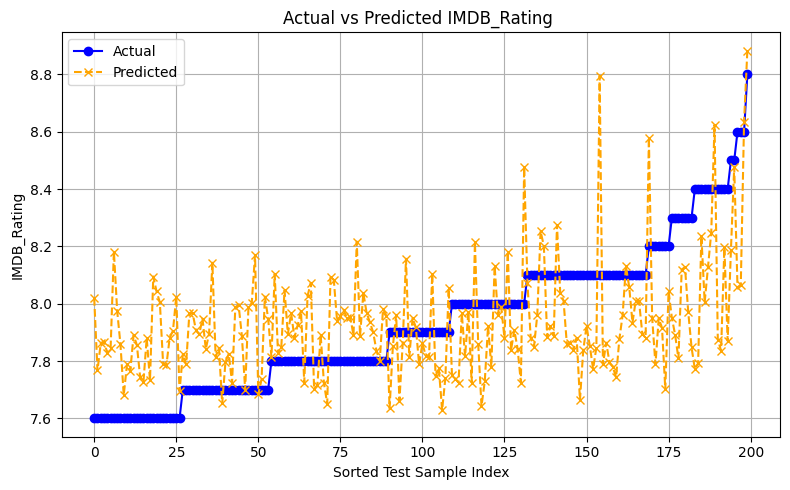


🔹 Classification Metrics :
Accuracy: 0.595

Classification Report:
               precision    recall  f1-score   support

     Average       0.59      0.81      0.68       109
         Hit       0.60      0.34      0.43        91

    accuracy                           0.59       200
   macro avg       0.60      0.57      0.56       200
weighted avg       0.60      0.59      0.57       200



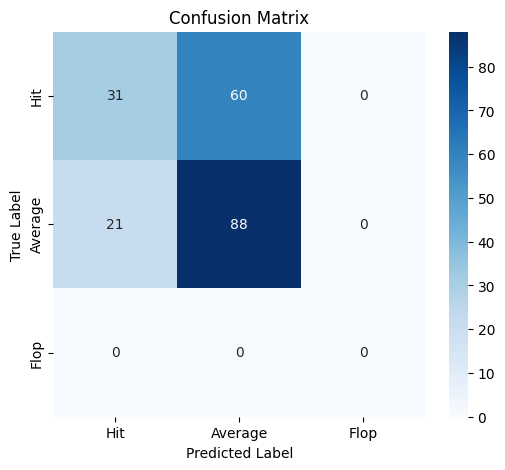

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from textblob import TextBlob
from sklearn.preprocessing import StandardScaler
import numpy as np

# -----------------------------
# Step 1: Load Dataset
# -----------------------------
df = pd.read_csv("/content/imdb_top_1000.csv", engine='python', on_bad_lines='skip')

# -----------------------------
# Step 2: Feature Engineering
# -----------------------------
df["Sentiment"] = df["Overview"].apply(lambda x: TextBlob(str(x)).sentiment.polarity)
features = ["No_of_Votes", "Sentiment"]
target = "IMDB_Rating"
df.dropna(subset=[target], inplace=True)
X = df[features]
y = df[target]

# -----------------------------
# Step 3: Scaling & Splitting
# -----------------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Use scaled data for splitting
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

# -----------------------------
# Step 4: RevanthRandomForestModel
# -----------------------------
class RevanthRandomForestModel:
    def __init__(self, n_estimators=100, random_state=42):
        self.model = RandomForestRegressor(
            n_estimators=n_estimators, random_state=random_state
        )

    def fit(self, X, y):
        self.model.fit(X, y)

    def predict(self, X):
        return self.model.predict(X)

# -----------------------------
# Step 5: Train & Predict
# -----------------------------
rev_rf_model = RevanthRandomForestModel()
rev_rf_model.fit(X_train, y_train)
y_pred = rev_rf_model.predict(X_test)

# -----------------------------
# Step 6: Evaluation
# -----------------------------
print("\nRevanthRandomForestModel Evaluation:")
print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

# -----------------------------
# Step 7: Visualization
# -----------------------------
plt.figure(figsize=(8, 5))
sorted_indices = np.argsort(y_test.values)
plt.plot(range(len(y_test)), y_test.values[sorted_indices], label="Actual", marker='o', color='blue')
plt.plot(range(len(y_pred)), y_pred[sorted_indices], label="Predicted", marker='x', color='orange', linestyle='--')
plt.title("Actual vs Predicted IMDB_Rating ")
plt.xlabel("Sorted Test Sample Index")
plt.ylabel("IMDB_Rating")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# -----------------------------
# Step 8: Categorize Ratings
# -----------------------------
def categorize_rating(r):
    if r >= 8.0:
        return "Hit"
    elif r >= 7.0:
        return "Average"
    else:
        return "Flop"

y_test_class = y_test.apply(categorize_rating)
y_pred_class = pd.Series(y_pred).apply(categorize_rating)

# -----------------------------
# Step 9: Classification Metrics
# -----------------------------
print("\n🔹 Classification Metrics :")
print("Accuracy:", accuracy_score(y_test_class, y_pred_class))
print("\nClassification Report:\n", classification_report(y_test_class, y_pred_class))

# Confusion Matrix Visualization
cm = confusion_matrix(y_test_class, y_pred_class, labels=["Hit", "Average", "Flop"])
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Hit", "Average", "Flop"],
            yticklabels=["Hit", "Average", "Flop"])
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()


2. RandomForestRegressor


🔹 RandomForestRegressor:
MAE: 0.21410999999999888
MSE: 0.06512221999999936
R2 Score: -0.015883876201162606

🔹 Classification Metrics:
Accuracy: 0.595

Classification Report:
               precision    recall  f1-score   support

     Average       0.59      0.81      0.68       109
         Hit       0.60      0.34      0.43        91

    accuracy                           0.59       200
   macro avg       0.60      0.57      0.56       200
weighted avg       0.60      0.59      0.57       200



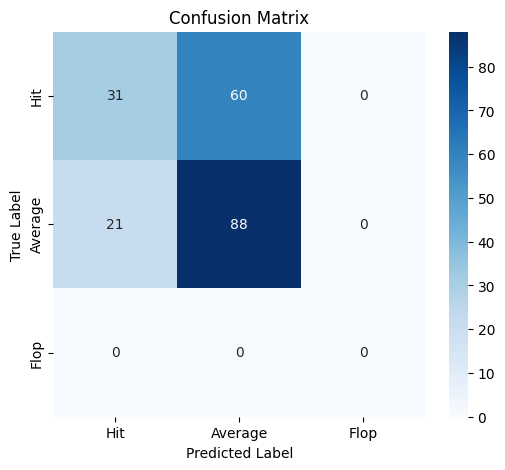

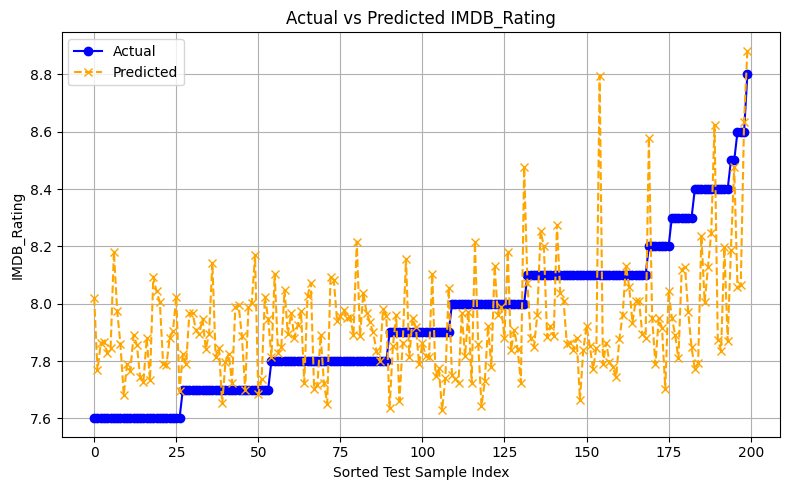

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    accuracy_score, classification_report, confusion_matrix
)
from textblob import TextBlob
from sklearn.preprocessing import StandardScaler
import numpy as np

# -----------------------------
# Step 1: Load Dataset
# -----------------------------
df = pd.read_csv("/content/imdb_top_1000.csv", engine='python', on_bad_lines='skip')

# -----------------------------
# Step 2: Feature Engineering
# -----------------------------
df["Sentiment"] = df["Overview"].apply(lambda x: TextBlob(str(x)).sentiment.polarity)
features = ["No_of_Votes", "Sentiment"]
target = "IMDB_Rating"
df.dropna(subset=[target], inplace=True)
X = df[features]
y = df[target]

# -----------------------------
# Step 3: Scaling & Splitting
# -----------------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

# -----------------------------
# Step 4: Random Forest Regressor
# -----------------------------
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# -----------------------------
# Step 5: Regression Evaluation
# -----------------------------
print("\n🔹 RandomForestRegressor:")
print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

# -----------------------------
# Step 6: Classification Evaluation
# -----------------------------
def categorize_rating(r):
    if r >= 8.0:
        return "Hit"
    elif r >= 7.0:
        return "Average"
    else:
        return "Flop"

y_test_class = y_test.apply(categorize_rating)
y_pred_class = pd.Series(y_pred).apply(categorize_rating)

print("\n🔹 Classification Metrics:")
print("Accuracy:", accuracy_score(y_test_class, y_pred_class))
print("\nClassification Report:\n", classification_report(y_test_class, y_pred_class))

# Confusion Matrix
cm = confusion_matrix(y_test_class, y_pred_class, labels=["Hit", "Average", "Flop"])
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Hit", "Average", "Flop"],
            yticklabels=["Hit", "Average", "Flop"])
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

# -----------------------------
# Step 7: Regression Visualization
# -----------------------------
plt.figure(figsize=(8, 5))
sorted_indices = np.argsort(y_test.values)
plt.plot(range(len(y_test)), y_test.values[sorted_indices], label="Actual", marker='o', color='blue')
plt.plot(range(len(y_pred)), y_pred[sorted_indices], label="Predicted", marker='x', color='orange', linestyle='--')
plt.title("Actual vs Predicted IMDB_Rating")
plt.xlabel("Sorted Test Sample Index")
plt.ylabel("IMDB_Rating")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


3. RevanthDecisionTreeModel


🔹 Regression Metrics:
Mean Absolute Error: 0.2005568730286878
Mean Squared Error: 0.06077604139346781
R2 Score: 0.0519149913660959

🔹 Classification Metrics:
Accuracy: 0.595

Classification Report:
               precision    recall  f1-score   support

     Average       0.58      0.94      0.72       109
         Hit       0.71      0.19      0.30        91

    accuracy                           0.59       200
   macro avg       0.64      0.56      0.51       200
weighted avg       0.64      0.59      0.52       200



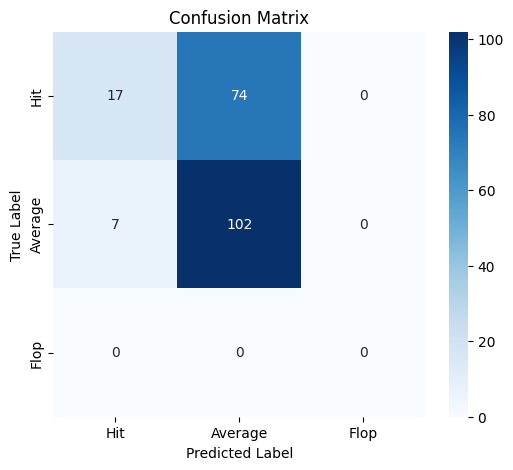

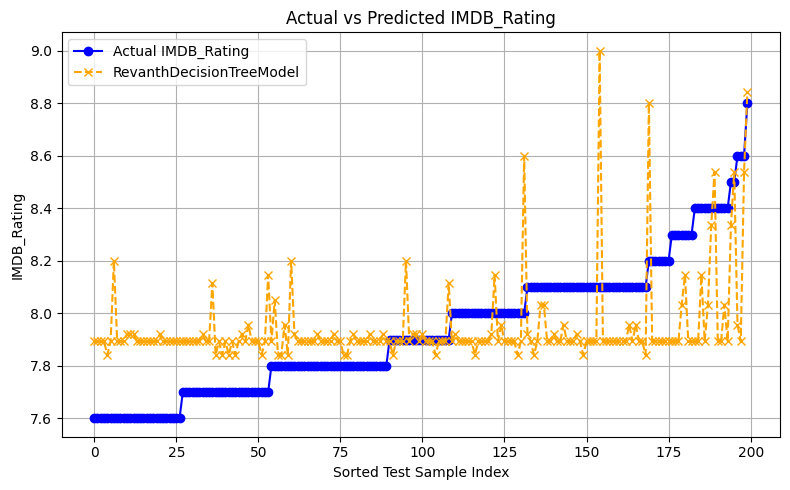

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    accuracy_score, classification_report, confusion_matrix
)
from textblob import TextBlob
import numpy as np
from sklearn.preprocessing import StandardScaler

# -----------------------------
# Step 1: Load Dataset
# -----------------------------
df = pd.read_csv("/content/imdb_top_1000.csv", engine='python', on_bad_lines='skip')

# -----------------------------
# Step 2: Feature Engineering
# -----------------------------
df["Sentiment"] = df["Overview"].apply(lambda x: TextBlob(str(x)).sentiment.polarity)
features = ["No_of_Votes", "Sentiment"]
target = "IMDB_Rating"
df.dropna(subset=[target], inplace=True)

X = df[features]
y = df[target]

# -----------------------------
# Step 3: Scaling & Splitting
# -----------------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

# -----------------------------
# Step 4: RevanthDecisionTreeModel
# -----------------------------
class RevanthDecisionTreeModel:
    def __init__(self, max_depth=5, random_state=42):
        self.model = DecisionTreeRegressor(max_depth=max_depth, random_state=random_state)

    def fit(self, X, y):
        self.model.fit(X, y)

    def predict(self, X):
        return self.model.predict(X)

# -----------------------------
# Step 5: Train & Predict
# -----------------------------
rev_dt_model = RevanthDecisionTreeModel(max_depth=5)
rev_dt_model.fit(X_train, y_train)
y_pred = rev_dt_model.predict(X_test)

# -----------------------------
# Step 6: Regression Evaluation
# -----------------------------
print("\n🔹 Regression Metrics:")
print("Mean Absolute Error:", mean_absolute_error(y_test, y_pred))
print("Mean Squared Error:", mean_squared_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

# -----------------------------
# Step 7: Classification Evaluation
# -----------------------------
def categorize_rating(r):
    if r >= 8.0:
        return "Hit"
    elif r >= 7.0:
        return "Average"
    else:
        return "Flop"

y_test_class = y_test.apply(categorize_rating)
y_pred_class = pd.Series(y_pred).apply(categorize_rating)

print("\n🔹 Classification Metrics:")
print("Accuracy:", accuracy_score(y_test_class, y_pred_class))
print("\nClassification Report:\n", classification_report(y_test_class, y_pred_class))

# Confusion Matrix
cm = confusion_matrix(y_test_class, y_pred_class, labels=["Hit", "Average", "Flop"])
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Hit", "Average", "Flop"],
            yticklabels=["Hit", "Average", "Flop"])
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

# -----------------------------
# Step 8: Regression Visualization
# -----------------------------
plt.figure(figsize=(8, 5))
sorted_indices = np.argsort(y_test.values)
plt.plot(range(len(y_test)), y_test.values[sorted_indices], label="Actual IMDB_Rating", marker='o', color='blue')
plt.plot(range(len(y_pred)), y_pred[sorted_indices], label="RevanthDecisionTreeModel", marker='x', linestyle='--', color='orange')
plt.title("Actual vs Predicted IMDB_Rating")
plt.xlabel("Sorted Test Sample Index")
plt.ylabel("IMDB_Rating")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


4. DecisionTreeRegressor


🔹 Regression Metrics:
Mean Absolute Error: 0.2005568730286878
Mean Squared Error: 0.06077604139346781
R2 Score: 0.0519149913660959

🔹 Classification Metrics (Decision Tree Regressor):
Accuracy: 0.595

Classification Report:
               precision    recall  f1-score   support

     Average       0.58      0.94      0.72       109
         Hit       0.71      0.19      0.30        91

    accuracy                           0.59       200
   macro avg       0.64      0.56      0.51       200
weighted avg       0.64      0.59      0.52       200



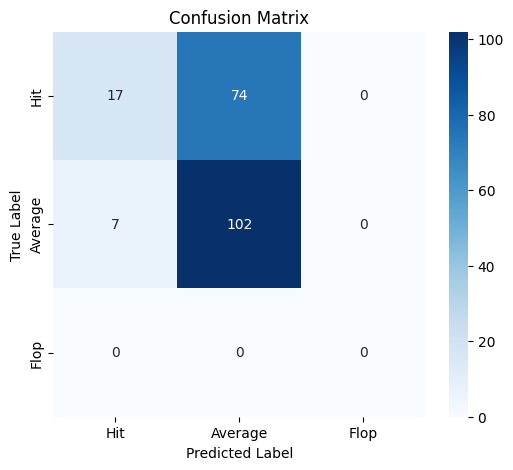

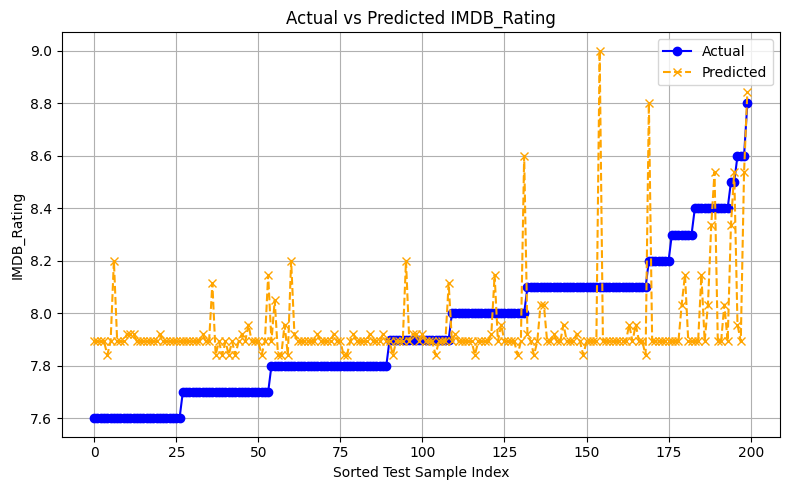

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    accuracy_score, classification_report, confusion_matrix
)
from textblob import TextBlob
import numpy as np
from sklearn.preprocessing import StandardScaler

# -----------------------------
# Step 1: Load Dataset
# -----------------------------
df = pd.read_csv("/content/imdb_top_1000.csv", engine='python', on_bad_lines='skip')

# -----------------------------
# Step 2: Feature Engineering
# -----------------------------
df["Sentiment"] = df["Overview"].apply(lambda x: TextBlob(str(x)).sentiment.polarity)
features = ["No_of_Votes", "Sentiment"]
target = "IMDB_Rating"
df.dropna(subset=[target], inplace=True)
X = df[features]
y = df[target]

# -----------------------------
# Step 3: Scaling & Split
# -----------------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

# -----------------------------
# Step 4: Train Decision Tree
# -----------------------------
model = DecisionTreeRegressor(max_depth=5, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# -----------------------------
# Step 5: Regression Evaluation
# -----------------------------
print("\n🔹 Regression Metrics:")
print("Mean Absolute Error:", mean_absolute_error(y_test, y_pred))
print("Mean Squared Error:", mean_squared_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

# -----------------------------
# Step 6: Classification Evaluation
# -----------------------------
def categorize_rating(r):
    if r >= 8.0:
        return "Hit"
    elif r >= 7.0:
        return "Average"
    else:
        return "Flop"

y_test_class = y_test.apply(categorize_rating)
y_pred_class = pd.Series(y_pred).apply(categorize_rating)

print("\n🔹 Classification Metrics (Decision Tree Regressor):")
print("Accuracy:", accuracy_score(y_test_class, y_pred_class))
print("\nClassification Report:\n", classification_report(y_test_class, y_pred_class))

# Confusion Matrix
cm = confusion_matrix(y_test_class, y_pred_class, labels=["Hit", "Average", "Flop"])
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Hit", "Average", "Flop"],
            yticklabels=["Hit", "Average", "Flop"])
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

# -----------------------------
# Step 7: Visualization
# -----------------------------
plt.figure(figsize=(8, 5))
sorted_indices = np.argsort(y_test.values)
plt.plot(range(len(y_test)), y_test.values[sorted_indices], label="Actual", marker='o', color='blue')
plt.plot(range(len(y_pred)), y_pred[sorted_indices], label="Predicted", marker='x', color='orange', linestyle='--')
plt.title("Actual vs Predicted IMDB_Rating")
plt.xlabel("Sorted Test Sample Index")
plt.ylabel("IMDB_Rating")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


5. Revanth's SVR Model


🔹 Regression Metrics (RevanthSVR):
Mean Absolute Error: 0.19169535248685088
Mean Squared Error: 0.05382097205696179
R2 Score: 0.16041164269060015

🔹 Classification Metrics (RevanthSVR):
Accuracy: 0.605

Classification Report:
               precision    recall  f1-score   support

     Average       0.59      0.93      0.72       109
         Hit       0.71      0.22      0.34        91

    accuracy                           0.60       200
   macro avg       0.65      0.57      0.53       200
weighted avg       0.65      0.60      0.54       200



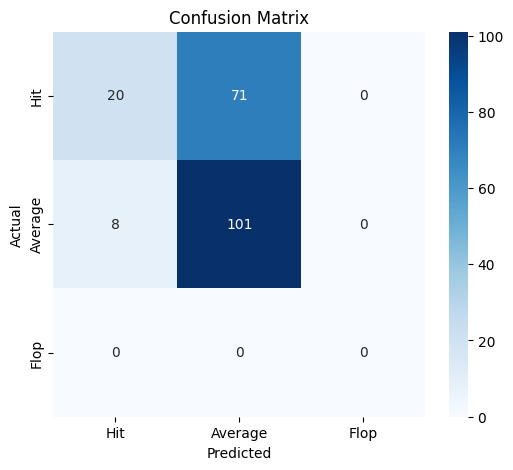

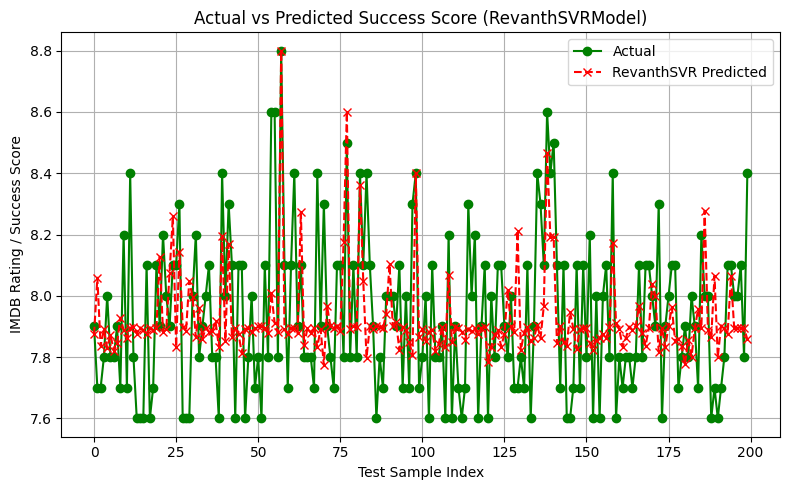

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVR
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    accuracy_score, classification_report, confusion_matrix
)
from textblob import TextBlob
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# -----------------------------
# Step 1: Sample Data
# -----------------------------
df = pd.read_csv("/content/imdb_top_1000.csv", engine='python', on_bad_lines='skip')

# -----------------------------
# Step 2: Feature Engineering
# -----------------------------
df["Sentiment"] = df["Overview"].apply(lambda x: TextBlob(str(x)).sentiment.polarity)
features = ["No_of_Votes", "Sentiment"]
target = "IMDB_Rating"
df.dropna(subset=[target], inplace=True)
X = df[features]
y = df[target]

# -----------------------------
# Step 3: Scaling & Split
# -----------------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

# -----------------------------
# Step 4: Revanth's SVR Model
# -----------------------------
class RevanthSVRModel:
    def __init__(self, kernel='rbf', C=1.0, epsilon=0.1):
        self.model = SVR(kernel=kernel, C=C, epsilon=epsilon)

    def fit(self, X, y):
        self.model.fit(X, y)

    def predict(self, X):
        preds = self.model.predict(X)
        return np.clip(preds, 0, 10)

# -----------------------------
# Step 5: Train and Predict
# -----------------------------
rev_svr_model = RevanthSVRModel()
rev_svr_model.fit(X_train, y_train)
y_pred_svr = rev_svr_model.predict(X_test)

# -----------------------------
# Step 6: Regression Evaluation
# -----------------------------
print("\n🔹 Regression Metrics (RevanthSVR):")
print("Mean Absolute Error:", mean_absolute_error(y_test, y_pred_svr))
print("Mean Squared Error:", mean_squared_error(y_test, y_pred_svr))
print("R2 Score:", r2_score(y_test, y_pred_svr))

# -----------------------------
# Step 7: Classification Evaluation
# -----------------------------
def categorize_rating(r):
    if r >= 8.0:
        return "Hit"
    elif r >= 7.0:
        return "Average"
    else:
        return "Flop"

y_test_class = y_test.apply(categorize_rating)
y_pred_class = pd.Series(y_pred_svr).apply(categorize_rating)

print("\n🔹 Classification Metrics (RevanthSVR):")
print("Accuracy:", accuracy_score(y_test_class, y_pred_class))
print("\nClassification Report:\n", classification_report(y_test_class, y_pred_class))

# Confusion Matrix Visualization

cm = confusion_matrix(y_test_class, y_pred_class, labels=["Hit", "Average", "Flop"])

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Hit", "Average", "Flop"],
            yticklabels=["Hit", "Average", "Flop"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# -----------------------------
# Step 8: Visualization
# -----------------------------
plt.figure(figsize=(8, 5))
plt.plot(range(len(y_test)), y_test.values, label="Actual", marker='o', color='green')
plt.plot(range(len(y_pred_svr)), y_pred_svr, label="RevanthSVR Predicted", marker='x', linestyle='--', color='red')
plt.title("Actual vs Predicted Success Score (RevanthSVRModel)")
plt.xlabel("Test Sample Index")
plt.ylabel("IMDB Rating / Success Score")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

6. SVR


🔹 SVR Regression Metrics:
Mean Absolute Error: 0.20261176474165488
Mean Squared Error: 0.06727464383830481
R2 Score: 0.15567911446799287

🔹 SVR Classification Metrics:
Accuracy: 0.5775

Classification Report:
               precision    recall  f1-score   support

     Average       0.55      0.93      0.70       207
         Hit       0.73      0.20      0.31       193

    accuracy                           0.58       400
   macro avg       0.64      0.56      0.50       400
weighted avg       0.64      0.58      0.51       400



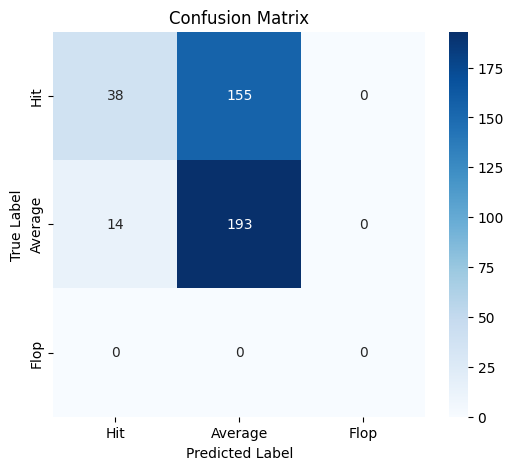

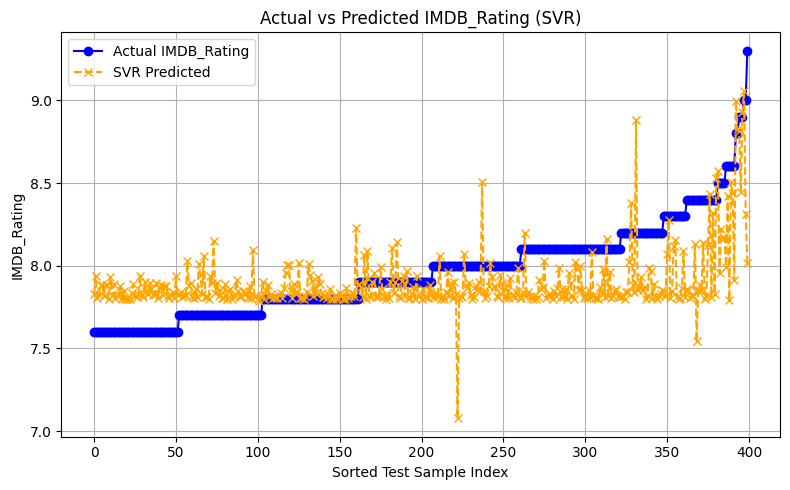

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    accuracy_score, classification_report
)
from textblob import TextBlob

# -----------------------------
# Step 1: Load Data
# -----------------------------
df = pd.read_csv("/content/imdb_top_1000.csv", engine='python', on_bad_lines='skip')

# -----------------------------
# Step 2: Feature Engineering
# -----------------------------
df["Sentiment"] = df["Overview"].apply(lambda x: TextBlob(str(x)).sentiment.polarity)

features = ["No_of_Votes", "Sentiment"]
target = "IMDB_Rating"

df.dropna(subset=[target], inplace=True)

X = df[features]
y = df[target]

# -----------------------------
# Step 3: Scaling & Split
# -----------------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.4, random_state=42
)

# -----------------------------
# Step 4: SVR Model
# -----------------------------
svr = SVR(kernel='rbf', C=100, gamma=0.1, epsilon=0.1)
svr.fit(X_train, y_train)
y_pred = svr.predict(X_test)

# -----------------------------
# Step 5: Regression Evaluation
# -----------------------------
print("\n🔹 SVR Regression Metrics:")
print("Mean Absolute Error:", mean_absolute_error(y_test, y_pred))
print("Mean Squared Error:", mean_squared_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

# -----------------------------
# Step 6: Classification Evaluation
# -----------------------------
def categorize_rating(r):
    if r >= 8.0:
        return "Hit"
    elif r >= 7.0:
        return "Average"
    else:
        return "Flop"

y_test_class = y_test.apply(categorize_rating)
y_pred_class = pd.Series(y_pred).apply(categorize_rating)

print("\n🔹 SVR Classification Metrics:")
print("Accuracy:", accuracy_score(y_test_class, y_pred_class))
print("\nClassification Report:\n", classification_report(y_test_class, y_pred_class))

# Confusion Matrix Visualization
cm = confusion_matrix(y_test_class, y_pred_class, labels=["Hit", "Average", "Flop"])
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Hit", "Average", "Flop"],
            yticklabels=["Hit", "Average", "Flop"])
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()


# -----------------------------
# Step 7: Visualization
# -----------------------------
plt.figure(figsize=(8, 5))
sorted_indices = np.argsort(y_test.values)
plt.plot(range(len(y_test)), y_test.values[sorted_indices], label="Actual IMDB_Rating", marker='o', color='blue')
plt.plot(range(len(y_pred)), y_pred[sorted_indices], label="SVR Predicted", marker='x', linestyle='--', color='orange')
plt.title("Actual vs Predicted IMDB_Rating (SVR)")
plt.xlabel("Sorted Test Sample Index")
plt.ylabel("IMDB_Rating")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


7. RevanthPredictor using linearregression


🔹 Regression Metrics:
Mean Absolute Error: 2.3685439709398484
Mean Squared Error: 5.755419115213574
R2 Score: -88.78252706872537

🔹 Classification Metrics:
Accuracy: 0.0

Classification Report:
               precision    recall  f1-score   support

     Average       0.00      0.00      0.00     109.0
        Flop       0.00      0.00      0.00       0.0
         Hit       0.00      0.00      0.00      91.0

    accuracy                           0.00     200.0
   macro avg       0.00      0.00      0.00     200.0
weighted avg       0.00      0.00      0.00     200.0



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_

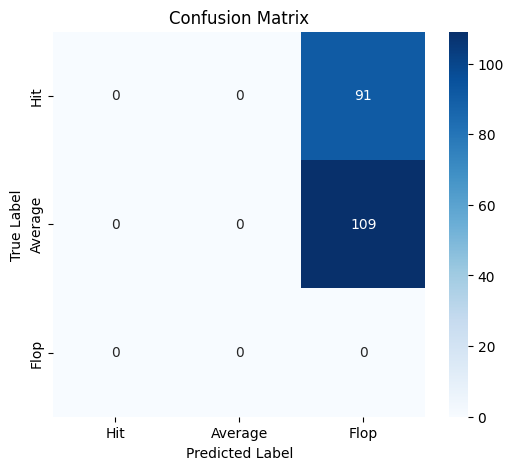

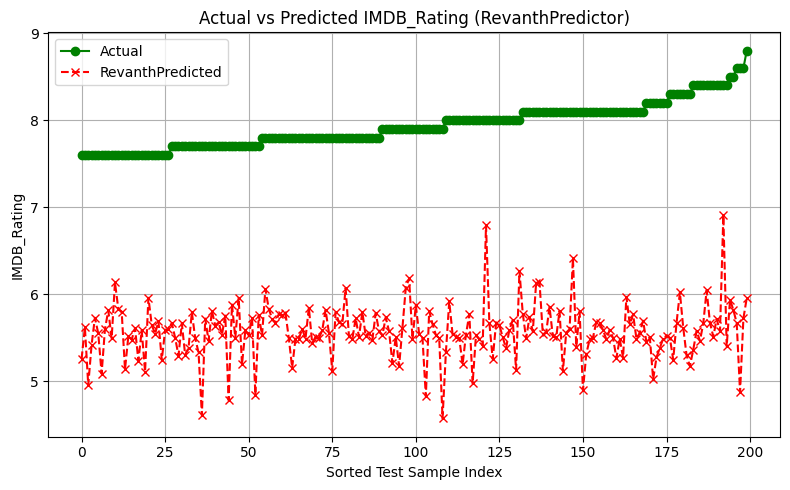

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    accuracy_score, classification_report
)
from textblob import TextBlob
from sklearn.linear_model import LinearRegression

# -----------------------------
# Step 1: Load Data
# -----------------------------
df = pd.read_csv("/content/imdb_top_1000.csv", engine='python', on_bad_lines='skip')

# -----------------------------
# Step 2: Feature Engineering
# -----------------------------
df["Sentiment"] = df["Overview"].apply(lambda x: TextBlob(str(x)).sentiment.polarity)

features = ["No_of_Votes", "Sentiment"]
target = "IMDB_Rating"

df.dropna(subset=[target], inplace=True)
X = df[features]
y = df[target]

# -----------------------------
# Step 3: Scaling & Split
# -----------------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

# -----------------------------
# Step 4: RevanthPredictor
# -----------------------------
class RevanthPredictor:
    def __init__(self, alpha=0.8):
        self.alpha = alpha
        self.model = LinearRegression()

    def fit(self, X, y, sentiment_col_name="Sentiment"):
        if sentiment_col_name in features:
            self.sentiment_index = features.index(sentiment_col_name)
        else:
            self.sentiment_index = None
        self.model.fit(X, y)

    def predict(self, X):
        base_pred = self.model.predict(X)
        if self.sentiment_index is not None:
            sentiment_component = X[:, self.sentiment_index]
            final_pred = self.alpha * base_pred + (1 - self.alpha) * sentiment_component
        else:
            final_pred = base_pred
        return np.clip(final_pred, 0, 10)

# -----------------------------
# Step 5: Train and Predict
# -----------------------------
revanth_model = RevanthPredictor(alpha=0.7)
revanth_model.fit(X_train, y_train, sentiment_col_name="Sentiment")
y_pred = revanth_model.predict(X_test)

# -----------------------------
# Step 6: Regression Evaluation
# -----------------------------
print("\n🔹 Regression Metrics:")
print("Mean Absolute Error:", mean_absolute_error(y_test, y_pred))
print("Mean Squared Error:", mean_squared_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

# -----------------------------
# Step 7: Classification Evaluation
# -----------------------------
def categorize_rating(r):
    if r >= 8.0:
        return "Hit"
    elif r >= 7.0:
        return "Average"
    else:
        return "Flop"

# Convert numeric ratings into categories
y_test_class = y_test.apply(categorize_rating)
y_pred_class = pd.Series(y_pred).apply(categorize_rating)

print("\n🔹 Classification Metrics:")
print("Accuracy:", accuracy_score(y_test_class, y_pred_class))
print("\nClassification Report:\n", classification_report(y_test_class, y_pred_class))

# Confusion Matrix Visualization
cm = confusion_matrix(y_test_class, y_pred_class, labels=["Hit", "Average", "Flop"])
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Hit", "Average", "Flop"],
            yticklabels=["Hit", "Average", "Flop"])
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()


# -----------------------------
# Step 8: Visualization
# -----------------------------
plt.figure(figsize=(8, 5))
sorted_indices = np.argsort(y_test.values)
plt.plot(range(len(y_test)), y_test.values[sorted_indices], label="Actual", marker='o', color='green')
plt.plot(range(len(y_pred)), y_pred[sorted_indices], label="RevanthPredicted", marker='x', linestyle='--', color='red')
plt.title("Actual vs Predicted IMDB_Rating (RevanthPredictor)")
plt.xlabel("Sorted Test Sample Index")
plt.ylabel("IMDB_Rating")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


8. LinearRegression


Linear Regression Evaluation:
Mean Absolute Error: 0.1970593601775026
Mean Squared Error: 0.056381320083226466
R2 Score: 0.12047110814884499

Linear Regression Evaluation:
Accuracy: 0.585

Classification Report:
               precision    recall  f1-score   support

     Average       0.59      0.82      0.68       109
         Hit       0.58      0.31      0.40        91

    accuracy                           0.58       200
   macro avg       0.58      0.56      0.54       200
weighted avg       0.58      0.58      0.55       200



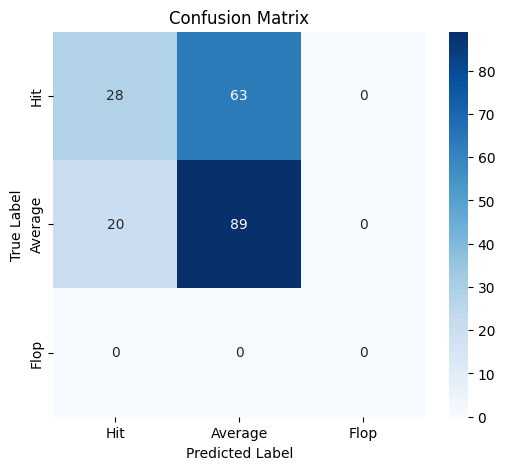

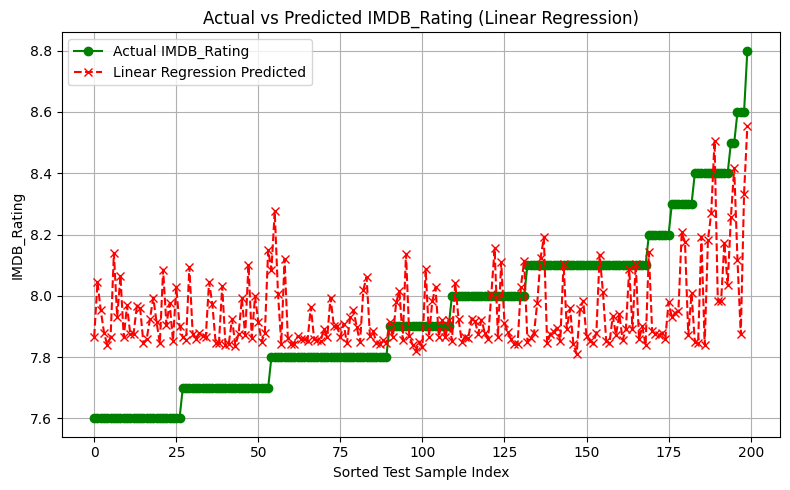

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    classification_report, accuracy_score
)
from textblob import TextBlob

# -----------------------------
# Step 1: Load Dataset
# -----------------------------
df = pd.read_csv("/content/imdb_top_1000.csv", engine='python', on_bad_lines='skip')

# -----------------------------
# Step 2: Feature Engineering
# -----------------------------
df["Sentiment"] = df["Overview"].apply(lambda x: TextBlob(str(x)).sentiment.polarity)

features = ["No_of_Votes", "Sentiment"]
target = "IMDB_Rating"

# Drop rows with missing target values
df.dropna(subset=[target], inplace=True)

X = df[features]
y = df[target]

# -----------------------------
# Step 3: Scaling & Split
# -----------------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

# -----------------------------
# Step 4: Linear Regression Model
# -----------------------------
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# -----------------------------
# Step 5: Regression Evaluation
# -----------------------------
print("\nLinear Regression Evaluation:")
print("Mean Absolute Error:", mean_absolute_error(y_test, y_pred))
print("Mean Squared Error:", mean_squared_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

# -----------------------------
# Step 6: Classification Evaluation
# -----------------------------
def categorize_rating(r):
    if r >= 8.0:
        return "Hit"
    elif r >= 7.0:
        return "Average"
    else:
        return "Flop"

# Convert to categorical labels
y_test_class = y_test.apply(categorize_rating)
y_pred_class = pd.Series(y_pred).apply(categorize_rating)

print("\nLinear Regression Evaluation:")
print("Accuracy:", accuracy_score(y_test_class, y_pred_class))
print("\nClassification Report:\n", classification_report(y_test_class, y_pred_class))

# Confusion Matrix Visualization
cm = confusion_matrix(y_test_class, y_pred_class, labels=["Hit", "Average", "Flop"])
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Hit", "Average", "Flop"],
            yticklabels=["Hit", "Average", "Flop"])
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()


# -----------------------------
# Step 7: Visualization
# -----------------------------
plt.figure(figsize=(8, 5))
sorted_indices = np.argsort(y_test.values)
plt.plot(range(len(y_test)), y_test.values[sorted_indices], label="Actual IMDB_Rating", marker='o', color='green')
plt.plot(range(len(y_pred)), y_pred[sorted_indices], label="Linear Regression Predicted", marker='x', linestyle='--', color='red')
plt.title("Actual vs Predicted IMDB_Rating (Linear Regression)")
plt.xlabel("Sorted Test Sample Index")
plt.ylabel("IMDB_Rating")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()



9. RevanthPredictor + RevanthSVRModel


RevanthPredictor (Linear + Sentiment) Evaluation:
MAE: 2.3685439709398484
MSE: 5.755419115213574
R2 Score: -88.78252706872537

RevanthSVRModel Evaluation:
MAE: 0.19169535248685088
MSE: 0.05382097205696179
R2 Score: 0.16041164269060015
Accuracy: 0.585

🔹 Classification Report - RevanthPredictor
              precision    recall  f1-score   support

     Average       0.00      0.00      0.00     109.0
        Flop       0.00      0.00      0.00       0.0
         Hit       0.00      0.00      0.00      91.0

    accuracy                           0.00     200.0
   macro avg       0.00      0.00      0.00     200.0
weighted avg       0.00      0.00      0.00     200.0


🔹 Classification Report - RevanthSVRModel
              precision    recall  f1-score   support

     Average       0.59      0.93      0.72       109
         Hit       0.71      0.22      0.34        91

    accuracy                           0.60       200
   macro avg       0.65      0.57      0.53       200
weighted

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_

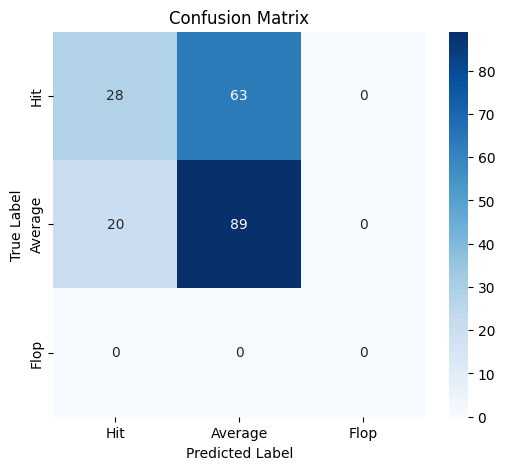

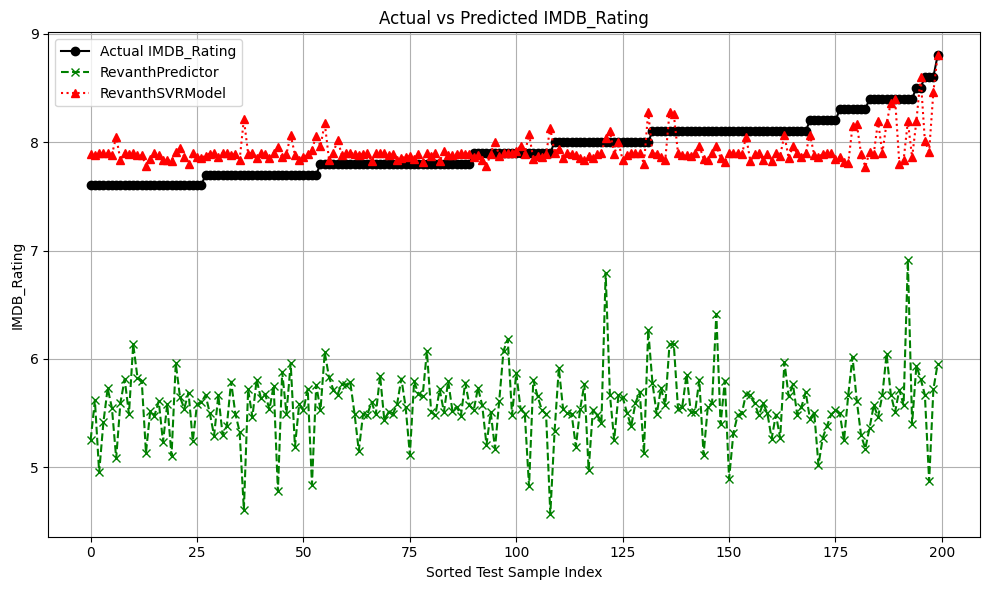

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    accuracy_score, precision_score, recall_score, f1_score, classification_report
)
from textblob import TextBlob

# -----------------------------
# Step 1: Load Dataset
# -----------------------------
df = pd.read_csv("/content/imdb_top_1000.csv", engine='python', on_bad_lines='skip')

# -----------------------------
# Step 2: Feature Engineering
# -----------------------------
df["Sentiment"] = df["Overview"].apply(lambda x: TextBlob(str(x)).sentiment.polarity)
features = ["No_of_Votes", "Sentiment"]
target = "IMDB_Rating"
df.dropna(subset=[target], inplace=True)
X = df[features]
y = df[target]

# -----------------------------
# Step 3: Scaling & Splitting
# -----------------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

# -----------------------------
# RevanthPredictor (Linear Regression + Sentiment Blend)
# -----------------------------
class RevanthPredictor:
    def __init__(self, alpha=0.8):
        self.alpha = alpha
        self.model = LinearRegression()
    def fit(self, X, y, sentiment_col_name="Sentiment"):
        if sentiment_col_name in df[features].columns:
            self.sentiment_index = df[features].columns.get_loc(sentiment_col_name)
        else:
            self.sentiment_index = None
        self.model.fit(X, y)
    def predict(self, X):
        base_pred = self.model.predict(X)
        if self.sentiment_index is not None:
            sentiment_component = X[:, self.sentiment_index]
            final_pred = self.alpha * base_pred + (1 - self.alpha) * sentiment_component
        else:
            final_pred = base_pred
        return np.clip(final_pred, 0, 10)

# -----------------------------
# RevanthSVRModel (SVR-based)
# -----------------------------
class RevanthSVRModel:
    def __init__(self, kernel='rbf', C=1.0, epsilon=0.1):
        self.model = SVR(kernel=kernel, C=C, epsilon=epsilon)

    def fit(self, X, y):
        self.model.fit(X, y)

    def predict(self, X):
        preds = self.model.predict(X)
        return np.clip(preds, 0, 10)

# -----------------------------
# Train and Predict with Both Models
# -----------------------------
rev_pred_model = RevanthPredictor(alpha=0.7)
rev_pred_model.fit(X_train, y_train)
y_pred_lr = rev_pred_model.predict(X_test)

rev_svr_model = RevanthSVRModel()
rev_svr_model.fit(X_train, y_train)
y_pred_svr = rev_svr_model.predict(X_test)

# -----------------------------
# Regression Evaluation
# -----------------------------
def evaluate_model(name, y_true, y_pred):
    print(f"\n{name} Evaluation:")
    print("MAE:", mean_absolute_error(y_true, y_pred))
    print("MSE:", mean_squared_error(y_true, y_pred))
    print("R2 Score:", r2_score(y_true, y_pred))

evaluate_model("RevanthPredictor (Linear + Sentiment)", y_test, y_pred_lr)
evaluate_model("RevanthSVRModel", y_test, y_pred_svr)

# -----------------------------
# Classification Evaluation
# -----------------------------
# Define categories from ratings
def categorize_rating(r):
    if r >= 8.0:
        return "Hit"
    elif r >= 7.0:
        return "Average"
    else:
        return "Flop"

y_test_class = y_test.apply(categorize_rating)
y_pred_lr_class = pd.Series(y_pred_lr).apply(categorize_rating)
y_pred_svr_class = pd.Series(y_pred_svr).apply(categorize_rating)

print("Accuracy:", accuracy_score(y_test_class, y_pred_class))

print("\n🔹 Classification Report - RevanthPredictor")
print(classification_report(y_test_class, y_pred_lr_class))

print("\n🔹 Classification Report - RevanthSVRModel")
print(classification_report(y_test_class, y_pred_svr_class))

# Confusion Matrix Visualization
cm = confusion_matrix(y_test_class, y_pred_class, labels=["Hit", "Average", "Flop"])
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Hit", "Average", "Flop"],
            yticklabels=["Hit", "Average", "Flop"])
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()


# -----------------------------
# Visualization - Regression
# -----------------------------
plt.figure(figsize=(10, 6))
sorted_indices = np.argsort(y_test.values)
plt.plot(range(len(y_test)), y_test.values[sorted_indices], label="Actual IMDB_Rating", marker='o', color='black')
plt.plot(range(len(y_pred_lr)), y_pred_lr[sorted_indices], label="RevanthPredictor", marker='x', linestyle='--', color='green')
plt.plot(range(len(y_pred_svr)), y_pred_svr[sorted_indices], label="RevanthSVRModel", marker='^', linestyle=':', color='red')
plt.title("Actual vs Predicted IMDB_Rating")
plt.xlabel("Sorted Test Sample Index")
plt.ylabel("IMDB_Rating")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


10. comparison graphs



🔹 Model Comparison Results:
              Model       MAE       MSE        R2  Accuracy
0        RevanthSVR  0.191695  0.053821  0.160412     0.605
1      RandomForest  0.214110  0.065122 -0.015884     0.595
2               SVR  0.196342  0.057403  0.104533     0.600
3  LinearRegression  0.197059  0.056381  0.120471     0.585


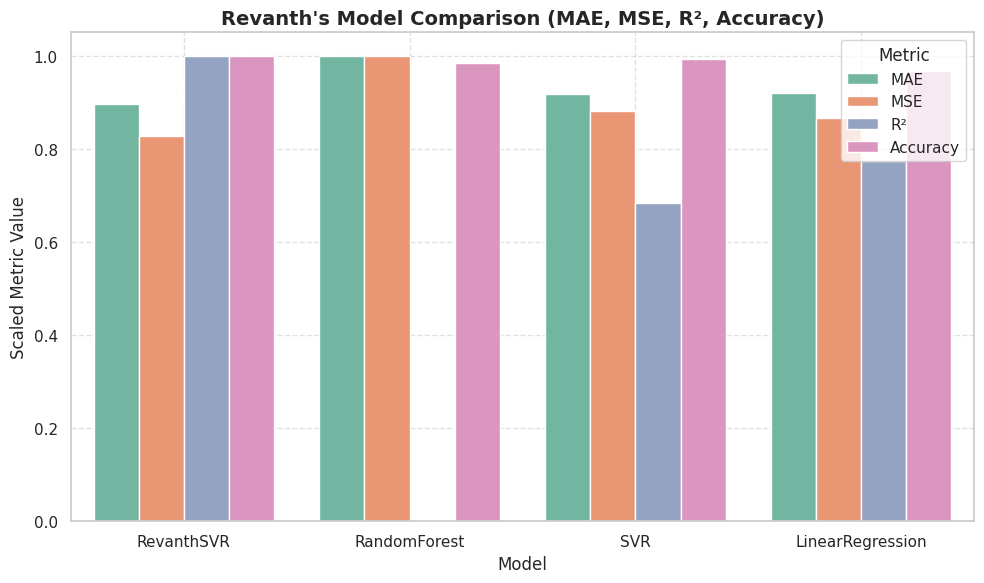

In [ ]:
# -----------------------------------------
# Revanth’s All-in-One Model Comparison Chart
# -----------------------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from textblob import TextBlob
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    accuracy_score
)

# -----------------------------
# Step 1: Load Dataset
# -----------------------------
df = pd.read_csv("/content/imdb_top_1000.csv", engine='python', on_bad_lines='skip')

# -----------------------------
# Step 2: Feature Engineering
# -----------------------------
df["Sentiment"] = df["Overview"].apply(lambda x: TextBlob(str(x)).sentiment.polarity)
features = ["No_of_Votes", "Sentiment"]
target = "IMDB_Rating"

df.dropna(subset=[target], inplace=True)
X = df[features]
y = df[target]

# -----------------------------
# Step 3: Scaling & Split
# -----------------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

# -----------------------------
# Step 4: Define Models
# -----------------------------
class RevanthSVRModel:
    def __init__(self, kernel='rbf', C=1.0, epsilon=0.1):
        self.model = SVR(kernel=kernel, C=C, epsilon=epsilon)
    def fit(self, X, y): self.model.fit(X, y)
    def predict(self, X): return np.clip(self.model.predict(X), 0, 10)

models = {
    "RevanthSVR": RevanthSVRModel(),
    "RandomForest": RandomForestRegressor(n_estimators=100, random_state=42),
    "SVR": SVR(kernel='rbf', C=100, gamma=0.1, epsilon=0.1),
    "LinearRegression": LinearRegression()
}

# -----------------------------
# Step 5: Train, Predict, Evaluate
# -----------------------------
metrics = []
def categorize_rating(r):
    if r >= 8.0: return "Hit"
    elif r >= 7.0: return "Average"
    else: return "Flop"

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    y_test_class = y_test.apply(categorize_rating)
    y_pred_class = pd.Series(y_pred).apply(categorize_rating)
    acc = accuracy_score(y_test_class, y_pred_class)

    metrics.append({
        "Model": name,
        "MAE": mae,
        "MSE": mse,
        "R2": r2,
        "Accuracy": acc
    })

results_df = pd.DataFrame(metrics)
print("\n🔹 Model Comparison Results:")
print(results_df)

# -----------------------------
# Step 6: Combined Visualization
# -----------------------------
# Normalize MSE and MAE for better comparison scaling
results_df["MAE_scaled"] = results_df["MAE"] / results_df["MAE"].max()
results_df["MSE_scaled"] = results_df["MSE"] / results_df["MSE"].max()
results_df["R2_scaled"] = (results_df["R2"] - results_df["R2"].min()) / (results_df["R2"].max() - results_df["R2"].min())
results_df["Accuracy_scaled"] = results_df["Accuracy"] / results_df["Accuracy"].max()

# Melt for plotting
melted = results_df.melt(id_vars="Model",
                         value_vars=["MAE_scaled", "MSE_scaled", "R2_scaled", "Accuracy_scaled"],
                         var_name="Metric", value_name="Value")

# Clean metric names
melted["Metric"] = melted["Metric"].replace({
    "MAE_scaled": "MAE",
    "MSE_scaled": "MSE",
    "R2_scaled": "R²",
    "Accuracy_scaled": "Accuracy"
})

# Plot grouped bar chart
plt.figure(figsize=(10,6))
sns.barplot(x="Model", y="Value", hue="Metric", data=melted, palette="Set2")
plt.title("Revanth's Model Comparison (MAE, MSE, R², Accuracy)", fontsize=14, fontweight="bold")
plt.xlabel("Model", fontsize=12)
plt.ylabel("Scaled Metric Value", fontsize=12)
plt.legend(title="Metric")
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()



🔹 Model Comparison Results:
              Model       MAE       MSE        R2  Accuracy
0        RevanthSVR  0.191695  0.053821  0.160412     0.605
1      RandomForest  0.214110  0.065122 -0.015884     0.595
2               SVR  0.196342  0.057403  0.104533     0.600
3  LinearRegression  0.197059  0.056381  0.120471     0.585


/tmp/ipython-input-1532031760.py:115: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x="Model", y=metric_name, data=results_df, palette=color)


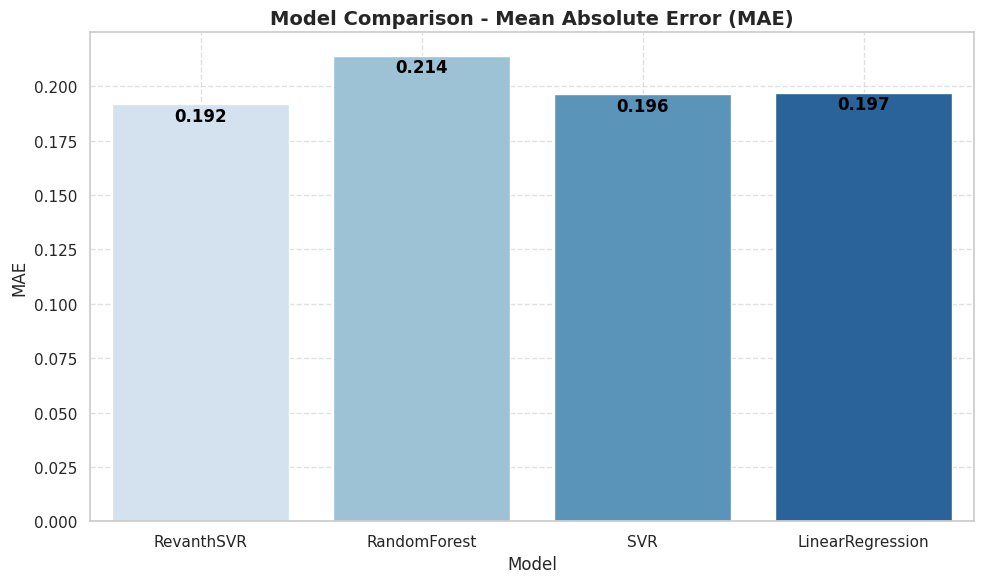

/tmp/ipython-input-1532031760.py:115: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x="Model", y=metric_name, data=results_df, palette=color)


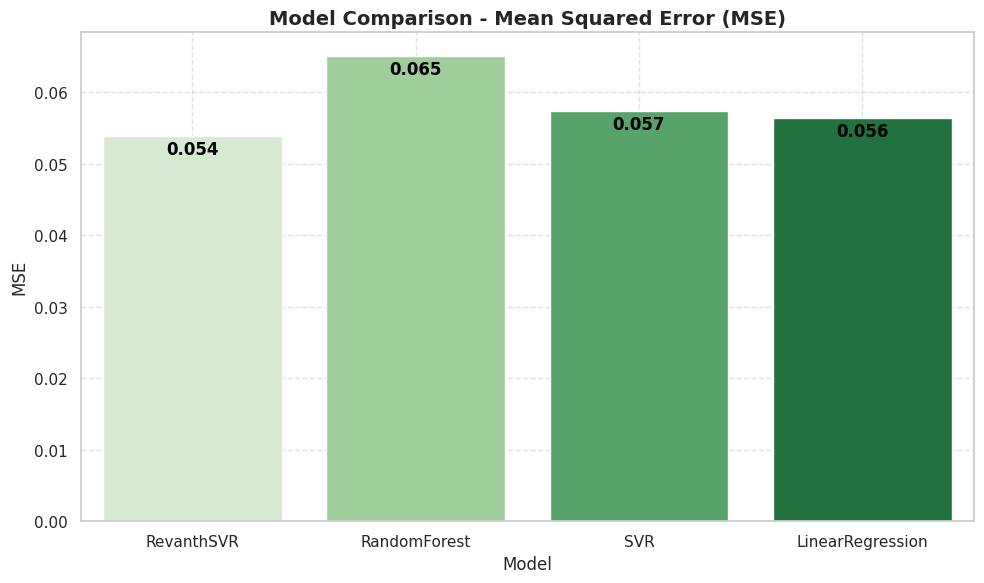

/tmp/ipython-input-1532031760.py:115: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x="Model", y=metric_name, data=results_df, palette=color)


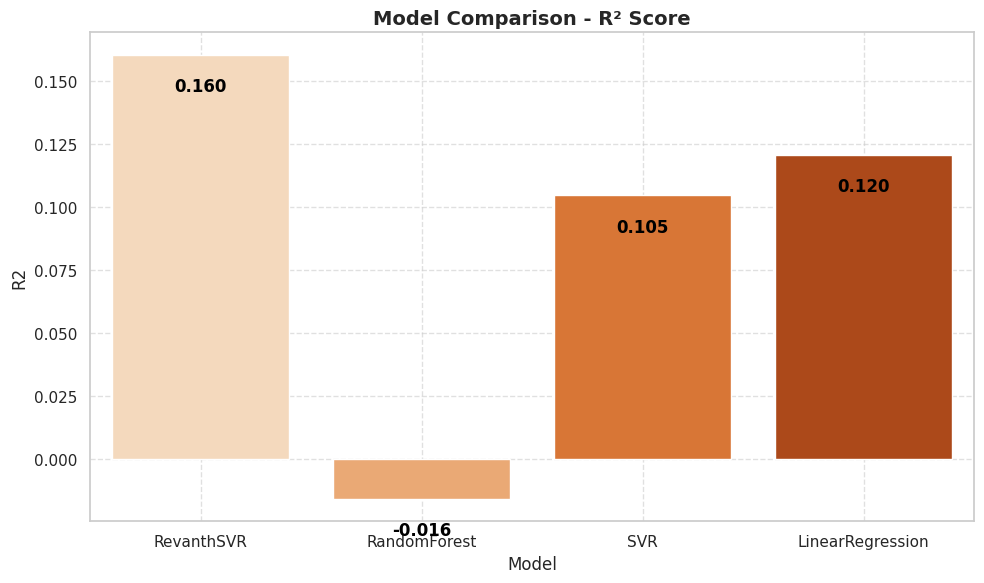

/tmp/ipython-input-1532031760.py:115: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x="Model", y=metric_name, data=results_df, palette=color)


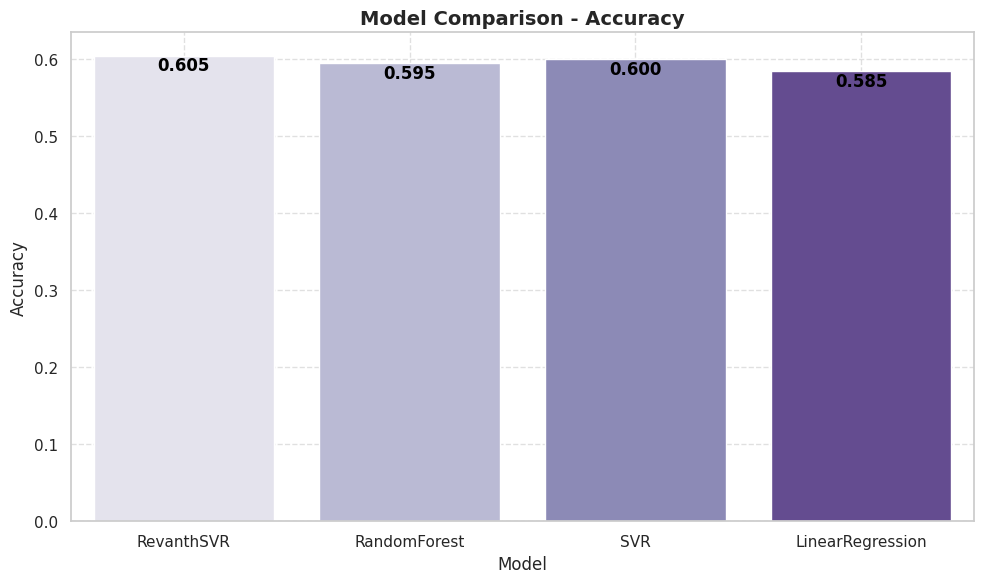

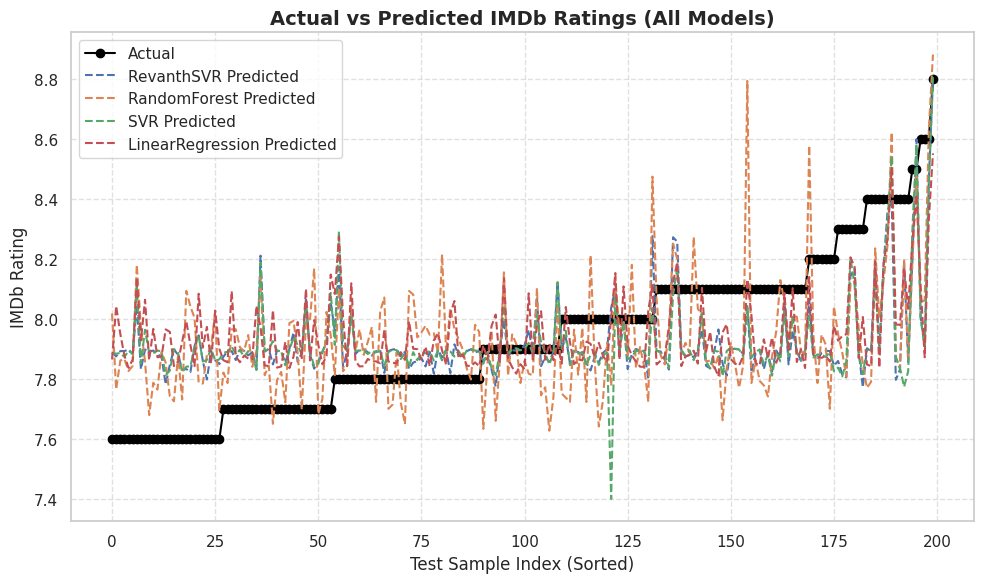

In [ ]:
# -----------------------------------------
# Revanth’s Comprehensive Model Comparison
# -----------------------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from textblob import TextBlob
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    accuracy_score
)

# -----------------------------
# Step 1: Load Dataset
# -----------------------------
df = pd.read_csv("/content/imdb_top_1000.csv", engine='python', on_bad_lines='skip')

# -----------------------------
# Step 2: Feature Engineering
# -----------------------------
df["Sentiment"] = df["Overview"].apply(lambda x: TextBlob(str(x)).sentiment.polarity)
features = ["No_of_Votes", "Sentiment"]
target = "IMDB_Rating"

df.dropna(subset=[target], inplace=True)
X = df[features]
y = df[target]

# -----------------------------
# Step 3: Scaling & Splitting
# -----------------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

# -----------------------------
# Step 4: Define Models
# -----------------------------
class RevanthSVRModel:
    def __init__(self, kernel='rbf', C=1.0, epsilon=0.1):
        self.model = SVR(kernel=kernel, C=C, epsilon=epsilon)

    def fit(self, X, y):
        self.model.fit(X, y)

    def predict(self, X):
        return np.clip(self.model.predict(X), 0, 10)


models = {
    "RevanthSVR": RevanthSVRModel(),
    "RandomForest": RandomForestRegressor(n_estimators=100, random_state=42),
    "SVR": SVR(kernel='rbf', C=100, gamma=0.1, epsilon=0.1),
    "LinearRegression": LinearRegression()
}

# -----------------------------
# Step 5: Train, Predict, Evaluate
# -----------------------------
metrics = []
y_pred_dict = {}

def categorize_rating(r):
    if r >= 8.0:
        return "Hit"
    elif r >= 7.0:
        return "Average"
    else:
        return "Flop"

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_pred_dict[name] = y_pred

    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    y_test_class = y_test.apply(categorize_rating)
    y_pred_class = pd.Series(y_pred).apply(categorize_rating)
    acc = accuracy_score(y_test_class, y_pred_class)

    metrics.append({
        "Model": name,
        "MAE": mae,
        "MSE": mse,
        "R2": r2,
        "Accuracy": acc
    })

# -----------------------------
# Step 6: Display Comparison Table
# -----------------------------
results_df = pd.DataFrame(metrics)
print("\n🔹 Model Comparison Results:")
print(results_df)

# -----------------------------
# Step 7: Fixed Visualization - Comparison Metrics
# -----------------------------
sns.set(style="whitegrid")

def plot_metric_bar(metric_name, title, color):
    plt.figure(figsize=(10,6))
    ax = sns.barplot(x="Model", y=metric_name, data=results_df, palette=color)

    # Dynamic offset for label placement
    max_val = results_df[metric_name].max()
    min_val = results_df[metric_name].min()
    offset = (max_val - min_val) * 0.05  # 5% offset

    for i, v in enumerate(results_df[metric_name]):
        ax.text(i,
                v - offset,             # place INSIDE bar
                f"{v:.3f}",
                ha='center',
                va='top',
                fontweight='bold',
                color='black')

    plt.title(title, fontsize=14, fontweight='bold')
    plt.xlabel("Model", fontsize=12)
    plt.ylabel(metric_name, fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()


plot_metric_bar("MAE", "Model Comparison - Mean Absolute Error (MAE)", "Blues")
plot_metric_bar("MSE", "Model Comparison - Mean Squared Error (MSE)", "Greens")
plot_metric_bar("R2", "Model Comparison - R² Score", "Oranges")
plot_metric_bar("Accuracy", "Model Comparison - Accuracy", "Purples")

# -----------------------------
# Step 8: Visualization - Actual vs Predicted
# -----------------------------
plt.figure(figsize=(10,6))
sorted_indices = np.argsort(y_test.values)

plt.plot(range(len(y_test)), y_test.values[sorted_indices], label="Actual", color='black', marker='o')

for name, y_pred in y_pred_dict.items():
    plt.plot(range(len(y_pred)), y_pred[sorted_indices], label=f"{name} Predicted", linestyle='--')

plt.title("Actual vs Predicted IMDb Ratings (All Models)", fontsize=14, fontweight='bold')
plt.xlabel("Test Sample Index (Sorted)")
plt.ylabel("IMDb Rating")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()



🔹 Model Comparison Results:
              Model       MAE       MSE        R2  Accuracy
0        RevanthSVR  0.191695  0.053821  0.160412     0.605
1      RandomForest  0.214110  0.065122 -0.015884     0.595
2               SVR  0.196342  0.057403  0.104533     0.600
3  LinearRegression  0.197059  0.056381  0.120471     0.585


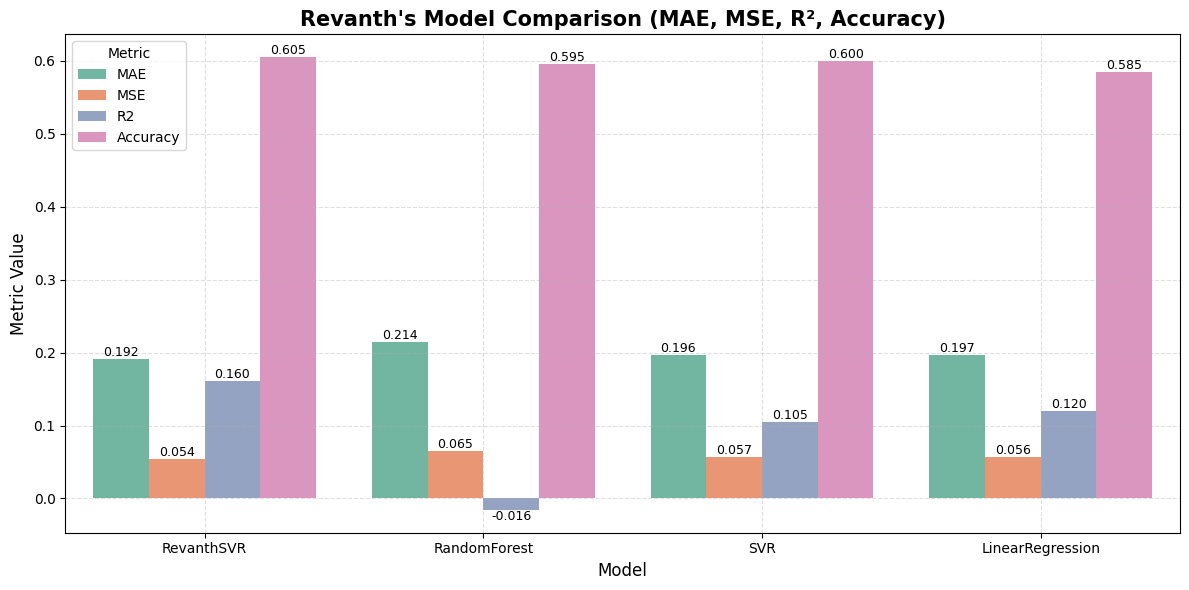

In [ ]:
# -----------------------------------------
# Revanth’s All-in-One Model Comparison Chart
# -----------------------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from textblob import TextBlob
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, accuracy_score

# -----------------------------
# Step 1: Load Dataset
# -----------------------------
df = pd.read_csv("/content/imdb_top_1000.csv", engine='python', on_bad_lines='skip')

# -----------------------------
# Step 2: Feature Engineering
# -----------------------------
df["Sentiment"] = df["Overview"].apply(lambda x: TextBlob(str(x)).sentiment.polarity)
features = ["No_of_Votes", "Sentiment"]
target = "IMDB_Rating"

df.dropna(subset=[target], inplace=True)
X = df[features]
y = df[target]

# -----------------------------
# Step 3: Scaling & Split
# -----------------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

# -----------------------------
# Step 4: Define Models
# -----------------------------
class RevanthSVRModel:
    def __init__(self, kernel='rbf', C=1.0, epsilon=0.1):
        self.model = SVR(kernel=kernel, C=C, epsilon=epsilon)
    def fit(self, X, y):
        self.model.fit(X, y)
    def predict(self, X):
        return np.clip(self.model.predict(X), 0, 10)

models = {
    "RevanthSVR": RevanthSVRModel(),
    "RandomForest": RandomForestRegressor(n_estimators=100, random_state=42),
    "SVR": SVR(kernel='rbf', C=100, gamma=0.1, epsilon=0.1),
    "LinearRegression": LinearRegression()
}

# -----------------------------
# Step 5: Train, Predict, Evaluate
# -----------------------------
metrics = []

def categorize_rating(r):
    if r >= 8.0:
        return "Hit"
    elif r >= 7.0:
        return "Average"
    else:
        return "Flop"

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    y_test_class = y_test.apply(categorize_rating)
    y_pred_class = pd.Series(y_pred).apply(categorize_rating)
    acc = accuracy_score(y_test_class, y_pred_class)

    metrics.append({
        "Model": name,
        "MAE": mae,
        "MSE": mse,
        "R2": r2,
        "Accuracy": acc
    })

results_df = pd.DataFrame(metrics)
print("\n🔹 Model Comparison Results:")
print(results_df)

# -----------------------------
# Step 6: Final Visualization (No 0.000 labels)
# -----------------------------
plot_df = results_df.melt(
    id_vars="Model",
    value_vars=["MAE", "MSE", "R2", "Accuracy"],
    var_name="Metric",
    value_name="Value"
)

plt.figure(figsize=(12, 6))
ax = sns.barplot(x="Model", y="Value", hue="Metric", data=plot_df, palette="Set2")

plt.title("Revanth's Model Comparison (MAE, MSE, R², Accuracy)", fontsize=15, fontweight="bold")
plt.xlabel("Model", fontsize=12)
plt.ylabel("Metric Value", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.4)

# Add labels (skip tiny values so 0.000 disappears)
for p in ax.patches:
    height = p.get_height()

    # ❌ Skip labels close to zero (remove 0.000)
    if abs(height) < 0.005:
        continue

    ax.annotate(
        f'{height:.3f}',
        (p.get_x() + p.get_width() / 2., height),
        ha='center',
        va='bottom' if height >= 0 else 'top',
        fontsize=9,
        color='black'
    )

plt.tight_layout()
plt.show()
